# Wpływ różnych praktyk na jakość PRów tworzonych przez agentów

## Praktyki
- ### Rozmiar PRa
    - #### liczba zmienionych plików
    - #### liczba zmienionych linii (oraz dodanych i usuniętych)
- ### Granularność commitów
    - #### liczba commitów (w danym PRze)
    - #### rozmiar commita (ilość zmian, średnia i maksymalna)
- ### Typ PRa
    - #### feat, fix, doc itp

## Wyznaczniki jakości
- ### czy PR został zmergowany
- ### czas do zmergowania (W godzinach)
- ### ilość komentarzy (inline, czyli do konkretnej zmiany oraz ogólnie pod issue)
- ### ilość żądanych zmian

In [ ]:
"""
Analysis pipeline for AIDev-pop:
    What practices correlate with the quality of Agentic-PRs?

Practices (independent vars):
    PR size            : loc_added, loc_deleted, loc_changed, files_changed
    Commit granularity : n_commits, mean_commit_size, max_commit_size
    Task type          : pr_task_type.type  (Conventional Commit category)
    Description        : title_len, body_len
    Linked issue       : has_linked_issue

Quality outcomes (dependent vars):
    is_merged                  -> logistic regression
    time_to_merge_hours        -> Cox proportional hazards (with censoring)
    n_inline_review_comments   -> negative binomial regression
    n_changes_requested        -> negative binomial regression

Controls:
    agent, log(repo_stars), repo_language (top-10 + "other")

Standard errors clustered at the repository level throughout.

Requirements:
    pip install pandas numpy scipy statsmodels lifelines matplotlib seaborn
"""

import os
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

INPUT   = "aidev_pop_pr_features.parquet"
OUT_DIR = "analysis_outputs"
FIG_DIR = os.path.join(OUT_DIR, "figs")
os.makedirs(FIG_DIR, exist_ok=True)


# =================================================================== #
# 1. Load + prep                                                       #
# =================================================================== #
def load_and_prep(path):
    df = pd.read_parquet(path)

    # Ensure timestamps are tz-aware datetimes
    for c in ["created_at", "closed_at", "merged_at"]:
        df[c] = pd.to_datetime(df[c], errors="coerce", utc=True)

    # Drop rows missing the essentials
    df = df.dropna(subset=["created_at", "is_merged", "repo_id"]).copy()

    # Log-transform skewed predictors (all >= 0; log1p handles zeros)
    for c in ["loc_added", "loc_deleted", "loc_changed", "files_changed",
              "n_commits", "mean_commit_size", "max_commit_size",
              "title_len", "body_len", "repo_stars"]:
        df[f"log_{c}"] = np.log1p(df[c].fillna(0))

    # Top-K language grouping
    top_langs = df["repo_language"].value_counts().head(10).index
    df["repo_language_grp"] = (
        df["repo_language"].where(df["repo_language"].isin(top_langs), other="other")
                            .fillna("other")
    )

    # Group rare task types (<100 PRs) into "other"
    keep = df["task_type"].value_counts()
    keep = keep[keep >= 100].index
    df["task_type_grp"] = (
        df["task_type"].where(df["task_type"].isin(keep), other="other")
                       .fillna("missing")
    )

    # Cox duration: merged -> time-to-merge; closed-unmerged -> time-to-close;
    # still open -> time since creation (censored)
    now = pd.Timestamp.now(tz="UTC")
    df["duration_hours"] = np.where(
        df["is_merged"] == 1,
        df["time_to_merge_hours"],
        np.where(
            df["closed_at"].notna(),
            df["time_to_close_hours"],
            (now - df["created_at"]).dt.total_seconds() / 3600,
        ),
    )
    df["event"] = df["is_merged"].astype(int)

    return df


# =================================================================== #
# 2. (deleted)                                                         #
# =================================================================== #


# =================================================================== #
# 3. Bivariate analysis                                                #
# =================================================================== #
def bivariate_continuous(df, practices, outcomes):
    rows = []
    for p in practices:
        for o in outcomes:
            sub = df[[p, o]].dropna()
            if len(sub) < 30:
                continue
            rho, pval = stats.spearmanr(sub[p], sub[o])
            rows.append({"practice": p, "outcome": o, "n": len(sub),
                         "spearman_rho": rho, "p_value": pval})
    return (pd.DataFrame(rows)
              .assign(abs_rho=lambda d: d["spearman_rho"].abs())
              .sort_values(["outcome", "abs_rho"], ascending=[True, False])
              .drop(columns="abs_rho"))


def kruskal_by_group(df, cat_col, num_col):
    groups = [g[num_col].dropna().values for _, g in df.groupby(cat_col)
              if len(g) >= 20]
    if len(groups) < 2:
        return np.nan, np.nan
    h, p = stats.kruskal(*groups)
    return h, p


def chi2_categorical_vs_binary(df, cat_col, outcome="is_merged"):
    ct = pd.crosstab(df[cat_col], df[outcome])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    rates = (df.groupby(cat_col)[outcome]
               .agg(merge_rate="mean", n="size")
               .sort_values("merge_rate", ascending=False))
    return chi2, p, dof, rates


# =================================================================== #
# 4. Multivariate models                                               #
# =================================================================== #
RHS = (
    "log_loc_added + log_loc_deleted + log_files_changed "
    "+ log_n_commits + log_mean_commit_size "
    "+ log_title_len + log_body_len + has_linked_issue "
    "+ C(task_type_grp) + C(agent) "
    "+ log_repo_stars + C(repo_language_grp)"
)


def fit_logistic_merge(df):
    return (smf.logit(f"is_merged ~ {RHS}", data=df)
               .fit(cov_type="cluster", cov_kwds={"groups": df["repo_id"]},
                    disp=False, maxiter=200))


def fit_negbin(df, outcome):
    sub = df.dropna(subset=[outcome])
    return (smf.negativebinomial(f"{outcome} ~ {RHS}", data=sub)
               .fit(cov_type="cluster", cov_kwds={"groups": sub["repo_id"]},
                    disp=False, maxiter=200))


def fit_cox_time_to_merge(df):
    cols = [
        "duration_hours", "event",
        "log_loc_added", "log_loc_deleted", "log_files_changed",
        "log_n_commits", "log_mean_commit_size",
        "log_title_len", "log_body_len", "has_linked_issue",
        "log_repo_stars", "task_type_grp", "agent", "repo_language_grp",
        "repo_id",
    ]
    cox_df = df[cols].dropna()
    cox_df = cox_df[cox_df["duration_hours"] > 0]
    cox_df = pd.get_dummies(
        cox_df,
        columns=["task_type_grp", "agent", "repo_language_grp"],
        drop_first=True,
    )
    cph = CoxPHFitter(penalizer=0.01)
    cph.fit(
        cox_df.drop(columns=["repo_id"]),
        duration_col="duration_hours",
        event_col="event",
        cluster_col=None,        # lifelines clustering: pass weights/strata if needed
        robust=True,
    )
    return cph


def tidy_summary(model, kind):
    """Return a clean coefficient table with effect sizes."""
    s = model.summary2().tables[1].copy()
    s.columns = [c.lower().replace(".", "").replace(" ", "_") for c in s.columns]
    if kind == "logit":
        s["odds_ratio"] = np.exp(s["coef"])
    elif kind == "negbin":
        s["irr"] = np.exp(s["coef"])      # incidence rate ratio
    return s


# =================================================================== #
# 5. Plots                                                             #
# =================================================================== #
def make_plots(df, m_logit):
    sns.set_theme(style="whitegrid")

    # Merge rate breakdowns
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df.groupby("task_type_grp")["is_merged"].mean().sort_values().plot(
        kind="barh", ax=axes[0], title="Merge rate by task type")
    df.groupby("agent")["is_merged"].mean().sort_values().plot(
        kind="barh", ax=axes[1], title="Merge rate by agent")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "merge_rate_breakdown.png"), dpi=120)
    plt.close()

    # Size / granularity vs outcomes
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(data=df, x="is_merged", y="log_loc_changed", ax=axes[0])
    axes[0].set_title("log(1 + lines changed) vs merged")
    sample = df.sample(min(5000, len(df)), random_state=0)
    sns.scatterplot(data=sample, x="log_loc_changed",
                    y="n_inline_review_comments", alpha=0.3, ax=axes[1])
    axes[1].set_title("PR size vs inline review comments")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "size_vs_outcomes.png"), dpi=120)
    plt.close()

    # Forest plot of odds ratios from logistic model
    s = tidy_summary(m_logit, "logit")
    s = s[~s.index.str.contains("Intercept|repo_language|C\\(agent\\)|C\\(task_type")]
    s = s.sort_values("odds_ratio")
    fig, ax = plt.subplots(figsize=(9, max(4, 0.3 * len(s))))
    ax.errorbar(
        s["odds_ratio"], range(len(s)),
        xerr=[s["odds_ratio"] - np.exp(s["[0025"]),
              np.exp(s["0975]"]) - s["odds_ratio"]],
        fmt="o", color="black"
    )
    ax.axvline(1, ls="--", color="red", alpha=0.5)
    ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index)
    ax.set_xscale("log"); ax.set_xlabel("Odds ratio (95% CI)")
    ax.set_title("Logistic: P(merged) — practice variables only")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "logit_forest.png"), dpi=120)
    plt.close()

## Ładowanie danych

In [6]:
df = load_and_prep(INPUT)
print("load_and_prep DONE...")

load_and_prep DONE...


## Eksploracyjna analiza danych (EDA)
Sprawdzenie jakości danych przed właściwą analizą:
- podstawowe informacje o DataFrame (rozmiar, typy kolumn),
- braki wartości,
- walidacja obecności pól wymaganych do dalszej analizy,
- zakres czasowy zbioru,
- statystyki opisowe zmiennych liczbowych,
- detekcja wartości odstających i niespójności,
- wizualizacja podstawowych rozkładów.

### Podstawowe informacje o DataFrame
Rozmiar, zużycie pamięci i typy kolumn.

In [8]:
print(f"Liczba wierszy (PRs)   : {len(df):,}")
print(f"Liczba kolumn          : {df.shape[1]}")
print(f"Pamięć (MB)            : {df.memory_usage(deep=True).sum() / 1024**2:.1f}")
print("\nLiczba kolumn wg typu:")
print(df.dtypes.value_counts().to_string())
print("\nWszystkie kolumny i typy:")
print(df.dtypes.to_string())

Liczba wierszy (PRs)   : 33,596
Liczba kolumn          : 55
Pamięć (MB)            : 115.0

Liczba kolumn wg typu:
int64                  23
float64                17
object                 12
datetime64[us, UTC]     3

Wszystkie kolumny i typy:
pr_id                                     int64
number                                    int64
title                                    object
body                                     object
agent                                    object
user_id                                   int64
user                                     object
state                                    object
created_at                  datetime64[us, UTC]
closed_at                   datetime64[us, UTC]
merged_at                   datetime64[us, UTC]
repo_id                                   int64
repo_url                                 object
html_url                                 object
is_merged                                 int64
is_closed_unmerged                

### Braki wartości
Procent brakujących wartości w każdej kolumnie. Pokazujemy wszystkie kolumny, w których cokolwiek brakuje. Niektóre braki są naturalne i oczekiwane:
- `merged_at` oraz `time_to_merge_hours` są puste dla każdego niezmergowanego PRa (zarówno otwartego, jak i zamkniętego bez zmergowania) — powinny mieć dokładnie tę samą liczbę braków,
- `closed_at` oraz `time_to_close_hours` są puste dla każdego PRa wciąż otwartego — również powinny się pokrywać liczbą braków.

In [9]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = (
    pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
      .sort_values("pct_missing", ascending=False)
)
missing_summary = missing_summary[missing_summary["n_missing"] > 0]
print(f"Kolumny z brakami: {len(missing_summary)} / {df.shape[1]}")
print(missing_summary.to_string())

Kolumny z brakami: 11 / 55
                     n_missing  pct_missing
std_commit_size          21570        64.20
time_to_merge_hours       9582        28.52
merged_at                 9582        28.52
closed_at                 2312         6.88
time_to_close_hours       2312         6.88
repo_license              1062         3.16
body                       360         1.07
repo_language              183         0.54
mean_commit_msg_len         16         0.05
mean_commit_size            16         0.05
max_commit_size             16         0.05


### Walidacja wymaganych pól
Każdy wiersz reprezentuje jeden PR — sprawdzamy, czy wszystkie pola krytyczne dla dalszej analizy są wypełnione i czy identyfikatory są unikalne.

In [10]:
# Pola wymagane do dalszej analizy — identyfikatory, czas, predyktory i wskaźniki jakości
required_fields = [
    # identyfikatory i metadane
    "pr_id", "repo_id", "agent", "state", "created_at",
    # wskaźniki jakości (zmienne zależne)
    "is_merged",
    # predyktory (rozmiar PR i granularność commitów)
    "loc_added", "loc_deleted", "n_commits", "files_changed",
]

report = []
for f in required_fields:
    if f not in df.columns:
        report.append({"field": f, "status": "MISSING COLUMN",
                       "n_missing": None, "pct_missing": None})
    else:
        n_miss = int(df[f].isna().sum())
        report.append({
            "field": f,
            "status": "OK" if n_miss == 0 else "HAS NULLS",
            "n_missing": n_miss,
            "pct_missing": round(n_miss / len(df) * 100, 2),
        })
print("Walidacja wymaganych pól:")
print(pd.DataFrame(report).to_string(index=False))

# Unikalność identyfikatorów i liczność kategorii
print(f"\npr_id unikalny?      {df['pr_id'].is_unique}  "
      f"({df['pr_id'].nunique():,} unikalnych z {len(df):,})")
print(f"liczba repozytoriów  {df['repo_id'].nunique():,}")
print(f"agenci               {sorted(df['agent'].dropna().unique().tolist())}")
print(f"stany PR             {sorted(df['state'].dropna().unique().tolist())}")
if "task_type" in df.columns:
    print(f"typy zadań           {df['task_type'].nunique()} unikalnych "
          f"(braki: {df['task_type'].isna().sum()})")

Walidacja wymaganych pól:
        field status  n_missing  pct_missing
        pr_id     OK          0          0.0
      repo_id     OK          0          0.0
        agent     OK          0          0.0
        state     OK          0          0.0
   created_at     OK          0          0.0
    is_merged     OK          0          0.0
    loc_added     OK          0          0.0
  loc_deleted     OK          0          0.0
    n_commits     OK          0          0.0
files_changed     OK          0          0.0

pr_id unikalny?      True  (33,596 unikalnych z 33,596)
liczba repozytoriów  2,807
agenci               ['Claude_Code', 'Copilot', 'Cursor', 'Devin', 'OpenAI_Codex']
stany PR             ['closed', 'open']
typy zadań           12 unikalnych (braki: 0)


### Zakres czasowy danych
Daty utworzenia PR — sprawdzenie ram czasowych zbioru i ewentualnych luk.

In [11]:
print(f"Najwcześniejszy PR   : {df['created_at'].min()}")
print(f"Najpóźniejszy PR     : {df['created_at'].max()}")
print(f"Rozpiętość (dni)     : {(df['created_at'].max() - df['created_at'].min()).days}")

# Rozkład PRów po miesiącach
prs_by_month = df.set_index("created_at").resample("ME").size()
print(f"\nLiczba PRów na miesiąc:")
print(prs_by_month.to_string())

Najwcześniejszy PR   : 2024-12-24 00:23:09+00:00
Najpóźniejszy PR     : 2025-07-30 19:36:13+00:00
Rozpiętość (dni)     : 218

Liczba PRów na miesiąc:
created_at
2024-12-31 00:00:00+00:00       65
2025-01-31 00:00:00+00:00      412
2025-02-28 00:00:00+00:00      539
2025-03-31 00:00:00+00:00      744
2025-04-30 00:00:00+00:00      819
2025-05-31 00:00:00+00:00     5771
2025-06-30 00:00:00+00:00    12107
2025-07-31 00:00:00+00:00    13139
Freq: ME


### Statystyki opisowe zmiennych liczbowych
Kluczowe predyktory (rozmiar PR, granularność commitów, długości opisu) i wskaźniki jakości — z percentylami 95/99 dla wykrycia ciężkich ogonów rozkładu.

In [12]:
numeric_cols = [
    "loc_added", "loc_deleted", "loc_churn", "files_changed",
    "n_commits", "mean_commit_size", "max_commit_size",
    "title_len", "body_len",
    "n_reviews", "n_inline_review_comments", "n_changes_requested",
    "n_approvals", "n_human_issue_comments", "n_linked_issues",
    "time_to_merge_hours", "time_to_close_hours",
]
numeric_cols = [c for c in numeric_cols if c in df.columns]
desc = df[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).T
print(desc.round(2).to_string())

                            count     mean       std  min     25%     50%     75%      95%       99%         max
loc_added                 33596.0  1285.79  12551.21  0.0   18.00   72.00  253.25  3658.00  24310.10  1053409.00
loc_deleted               33596.0   686.45  10299.41  0.0    1.00   10.00   65.00  1440.25  11441.80   981515.00
files_changed             33596.0    17.14     55.08  0.0    1.00    3.00    8.00    80.00    301.00     1641.00
n_commits                 33596.0     2.64      3.96  0.0    1.00    1.00    2.00     9.00     24.00       30.00
mean_commit_size          33580.0   640.21   6200.76  0.0   18.50   62.79  192.00  1730.01   9794.51   643423.00
max_commit_size           33580.0  1427.03  13103.72  0.0   24.00   84.00  276.00  3983.15  27148.87  1053342.00
title_len                 33596.0    42.85     18.13  1.0   30.00   39.00   51.00    77.00     95.00      351.00
body_len                  33596.0   930.84   1651.27  0.0  273.00  383.00  935.25  3368.25   550

#### Komentarz: gdzie są ciężkie ogony?

**Ekstremalnie skośne** (średnia ≫ mediana, 99. percentyl wielokrotnie większy od 75., max większy o rzędy wielkości):

| kolumna | mediana | średnia | 99. percentyl | max |
|---|---:|---:|---:|---:|
| `loc_added` | 72 | 1 286 | 24 310 | **1 053 409** |
| `loc_deleted` | 10 | 686 | 11 442 | 981 515 |
| `mean_commit_size` | 63 | 640 | 9 795 | 643 423 |
| `max_commit_size` | 84 | 1 427 | 27 149 | 1 053 342 |
| `files_changed` | 3 | 17 | 301 | 1 641 |
| `body_len` | 383 | 931 | 5 502 | 77 435 |

Średnia jest 10–70× większa od mediany — czyli kilka gigantycznych PRów (prawdopodobnie boilerplate / dane, podobnie jak `llms.txt` z 22 923 linii w przykładzie z `pr_commit_details`) zaburza obraz. Top 5 PRów po `loc_changed` z komórki niżej to wszystko PRy Copilota z >725 tys. zmienionych linii — niemal na pewno commity z wygenerowanymi/wielkimi plikami.

**Wskaźniki jakości z silną asymetrią i nadmiarem zer** (większość PRów ma `0`, ale ogon sięga kilkudziesięciu):
- `n_inline_review_comments` — mediana 0, max 159
- `n_reviews` — mediana 0, max 30
- `n_changes_requested` — mediana 0, max 19 (w praktyce zmienna prawie binarna)
- `n_human_issue_comments` — mediana 0, max 28

**Czasy** (bardzo ciężki ogon + sygnał bimodalności):
- `time_to_merge_hours` — mediana **0.05 h (≈ 3 min!)**, średnia 19 h, max 1 798 h (≈ 75 dni)
- `time_to_close_hours` — mediana 0.12 h, max 3 549 h (≈ 148 dni)

Mediana w okolicach 3 minut sugeruje, że duża część zmergowanych PRów to **auto-merge** (CI lub bot kliknął "merge" niemal natychmiast po utworzeniu) — to inna populacja niż PRy faktycznie przeglądane przez człowieka.

**Stosunkowo "normalne" rozkłady** (mean ≈ median, max w sensownym zakresie):
- `title_len` (mediana 39, max 351),
- `n_commits` (mediana 1, max 30 — ograniczone od góry).

#### Jak to wpływa na dalszą pracę?

1. **Transformacje log** — bez `log1p` na predyktorach wszystkie modele byłyby zdominowane przez pojedyncze PRy z milionem linii. `load_and_prep` to robi (`log_loc_added`, `log_n_commits`, …).
2. **Korelacja Spearmana zamiast Pearsona** — Pearson opiera się na średniej i odchyleniu, więc na takich ogonach byłby bezużyteczny. Używamy rang (w `bivariate_continuous`).
3. **Modele liczników**: regresja ujemna dwumianowa (NB) dla `n_inline_review_comments` i `n_changes_requested` — radzi sobie z **nadrozproszeniem** (variancja ≫ średnia) i nadmiarem zer dużo lepiej niż Poisson czy OLS (jej używamy).
4. **Analiza przeżycia (Cox)** dla `time_to_merge` — bo (a) rozkład jest mocno asymetryczny, (b) trzeba uwzględnić cenzurowanie po prawej (PRy otwarte i zamknięte bez mergu nie mają "czasu do mergu") (już zrobione).
5. **Mediany, nie średnie** w statystykach opisowych - Średnia 1 286 linii dodanych nic nie powiedziałaby o typowym PRze (typowy ma 72).
6. **Klastrowanie błędów standardowych po `repo_id`** — pojedyncze repozytoria z setkami PRów (np. auto-mergowanych) nie powinny dawać sztucznie zawyżonej istotności (już zrobione).
7. **Uważać przy interpretacji wartości skrajnych** — `max_commit_size` ≈ 1 M linii to niemal na pewno wygenerowany plik. Te obserwacje warto trzymać (po log są nieszkodliwe), ale **nie** dawać ich jako "typowy duży PR".
8. **Potencjalna bimodalność czasu do mergu** sugeruje, że w pogłębionej analizie warto byłoby albo (a) odfiltrować auto-mergowane PRy (np. `time_to_merge_hours < 0.1`), albo (b) modelować je osobno — bo mieszają się tu dwa różne procesy ("auto-pilot" i "review przez człowieka").

### Wartości odstające i kontrola spójności
Sprawdzenie:
- czy w kolumnach licznikowych nie pojawiają się wartości ujemne (nie powinny),
- ile jest PRów bez zmian kodu i bez commitów (możliwe artefakty zbierania danych),
- czy nie ma niespójności między `is_merged`, `merged_at` i `time_to_merge_hours`,
- jak wyglądają największe wartości skrajne.

In [13]:
# Sprawdzenie wartości ujemnych tam, gdzie nie powinny występować (liczniki, długości)
nonneg_cols = [
    "loc_added", "loc_deleted", "loc_churn", "files_changed",
    "n_commits", "n_reviews", "n_inline_review_comments",
    "n_changes_requested", "n_approvals", "n_human_issue_comments",
    "title_len", "body_len",
]
nonneg_cols = [c for c in nonneg_cols if c in df.columns]
print("Wartości ujemne w kolumnach, które powinny być >= 0:")
any_neg = False
for c in nonneg_cols:
    n_neg = (df[c] < 0).sum()
    if n_neg > 0:
        print(f"  {c}: {n_neg}")
        any_neg = True
if not any_neg:
    print("  (brak — wszystkie OK)")

# PRy bez żadnych zmian kodu
loc_col = "loc_changed" if "loc_changed" in df.columns else "loc_churn"
n_zero_changes = (df[loc_col].fillna(0) == 0).sum()
print(f"\nPRy bez zmian kodu ({loc_col} == 0): "
      f"{n_zero_changes:,} ({n_zero_changes / len(df) * 100:.2f}%)")

# PRy bez commitów (możliwe gdy commit_files puste)
n_no_commits = (df["n_commits"].fillna(0) == 0).sum()
print(f"PRy bez commitów (n_commits == 0): "
      f"{n_no_commits:,} ({n_no_commits / len(df) * 100:.2f}%)")

# Spójność: oznaczone jako merged ale bez merged_at
n_inconsistent_merge = ((df["is_merged"] == 1) & df["merged_at"].isna()).sum()
print(f"\nNiespójność: is_merged == 1 ale merged_at == NaT: {n_inconsistent_merge}")

# Spójność: nie-zmergowane, a mają time_to_merge_hours
n_unmerged_with_ttm = ((df["is_merged"] == 0) & df["time_to_merge_hours"].notna()).sum()
print(f"Niespójność: is_merged == 0 ale time_to_merge_hours != NaN: "
      f"{n_unmerged_with_ttm}")

# Ekstremalne PRy - top 5 po wielkości
print(f"\nNajwiększe PRy (top 5 po {loc_col}):")
cols_show = [c for c in ["pr_id", "agent", loc_col, "files_changed",
                          "n_commits", "task_type"] if c in df.columns]
print(df.nlargest(5, loc_col)[cols_show].to_string(index=False))

Wartości ujemne w kolumnach, które powinny być >= 0:
  (brak — wszystkie OK)

PRy bez zmian kodu (loc_changed == 0): 518 (1.54%)
PRy bez commitów (n_commits == 0): 16 (0.05%)

Niespójność: is_merged == 1 ale merged_at == NaT: 0
Niespójność: is_merged == 0 ale time_to_merge_hours != NaN: 0

Największe PRy (top 5 po loc_changed):
     pr_id   agent  loc_changed  files_changed  n_commits task_type
3109581531 Copilot      1964377             34          5      feat
3180142640 Copilot      1451946            468         30      feat
3127181957 Copilot      1053412            112          4      test
3271677684 Copilot      1046823            296          7      feat
3276981020 Copilot       725992             19          2       fix


### Wizualizacja podstawowych rozkładów
Szybki rzut oka na rozkłady kluczowych zmiennych: agenci, typy zadań, stany, rozmiar PR, liczba commitów i czas do zmergowania.

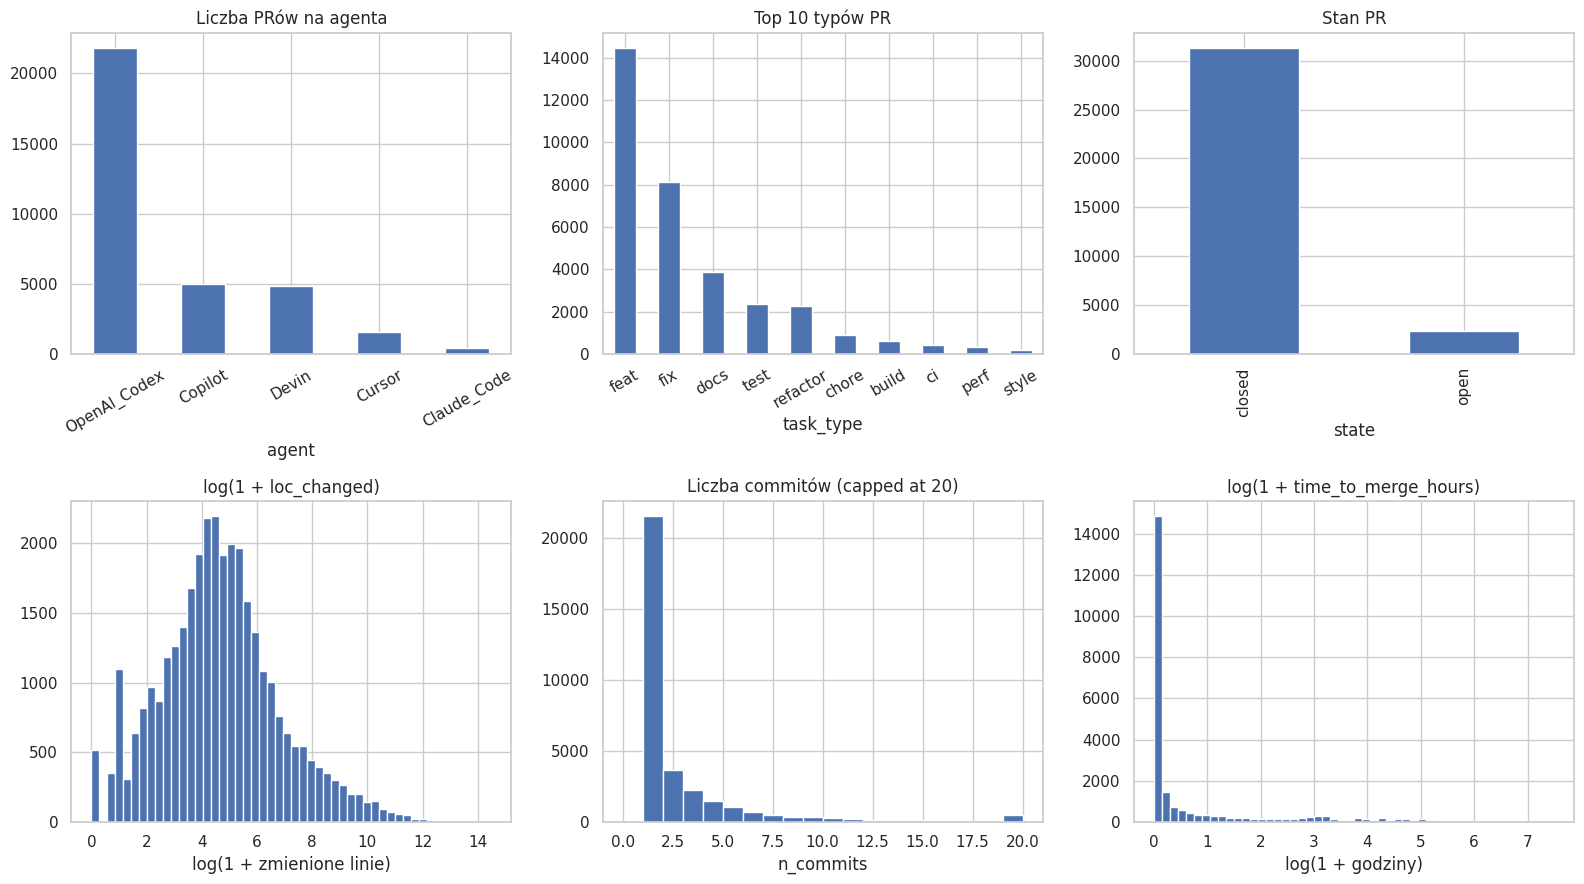

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Rozkład agentów
df["agent"].value_counts().plot(
    kind="bar", ax=axes[0, 0], title="Liczba PRów na agenta")
axes[0, 0].tick_params(axis="x", rotation=30)

# Rozkład typów zadań
df["task_type"].fillna("missing").value_counts().head(10).plot(
    kind="bar", ax=axes[0, 1], title="Top 10 typów PR")
axes[0, 1].tick_params(axis="x", rotation=30)

# Rozkład stanów
df["state"].value_counts().plot(
    kind="bar", ax=axes[0, 2], title="Stan PR")

# Rozkład wielkości PR (log)
loc_col = "loc_changed" if "loc_changed" in df.columns else "loc_churn"
axes[1, 0].hist(np.log1p(df[loc_col].fillna(0)), bins=50)
axes[1, 0].set_title(f"log(1 + {loc_col})")
axes[1, 0].set_xlabel("log(1 + zmienione linie)")

# Rozkład liczby commitów (przycięty do 20)
axes[1, 1].hist(df["n_commits"].clip(upper=20), bins=20)
axes[1, 1].set_title("Liczba commitów (capped at 20)")
axes[1, 1].set_xlabel("n_commits")

# Rozkład czasu do mergu (log)
ttm = df["time_to_merge_hours"].dropna()
axes[1, 2].hist(np.log1p(ttm), bins=50)
axes[1, 2].set_title("log(1 + time_to_merge_hours)")
axes[1, 2].set_xlabel("log(1 + godziny)")

plt.tight_layout()
plt.show()

## Korelacje między praktykami a wyznacznikami jakości
(między zmiennymi liczbowymi)

Ogólna zasada dla współczynnika ρ (rho) Spearmana:
|ρ| ≈ 0.0–0.1 → praktycznie brak związku; 0.1–0.3 → słaby; 0.3–0.5 → umiarkowany; 0.5–0.7 → silny; 0.7+ → bardzo silny. Znak wskazuje kierunek.

In [12]:
practices = ["log_loc_added", "log_loc_deleted", "log_loc_changed",
                "log_files_changed", "log_n_commits", "log_mean_commit_size",
                "log_max_commit_size", "log_title_len", "log_body_len"]
outcomes  = ["is_merged", "time_to_merge_hours",
                "n_inline_review_comments", "n_changes_requested"]

print("=" * 72)
print("BIVARIATE: Spearman correlations (practice vs outcome)")
print("=" * 72)
biv = bivariate_continuous(df, practices, outcomes)
print(biv.to_string(index=False))
biv.to_csv(os.path.join(OUT_DIR, "bivariate_spearman.csv"), index=False)

BIVARIATE: Spearman correlations (practice vs outcome)
            practice                  outcome     n  spearman_rho       p_value
        log_body_len                is_merged 33596     -0.251257  0.000000e+00
       log_n_commits                is_merged 33596     -0.225817  0.000000e+00
       log_title_len                is_merged 33596     -0.210159  0.000000e+00
       log_loc_added                is_merged 33596     -0.139348 2.824099e-145
     log_loc_changed                is_merged 33596     -0.138559 1.212671e-143
 log_max_commit_size                is_merged 33596     -0.120199 2.481440e-108
     log_loc_deleted                is_merged 33596     -0.091650  1.385248e-63
   log_files_changed                is_merged 33596     -0.078990  1.203939e-47
log_mean_commit_size                is_merged 33596     -0.068204  6.153746e-36
       log_n_commits      n_changes_requested 33596      0.252731  0.000000e+00
        log_body_len      n_changes_requested 33596      0.172369

#### liczba commitów w PRze (dość) silnie koreluje z czasem do zmergowania i ilością komentarzy do zmian
(pozytywna korelacja, czyli im więcej commitów tym dłuższy czas do zmergowania)
#### ale tylko słabo koreluje z tym, czy PR został zmergowany i ilością żądanych zmian
co wydaje się być prawdziwym miernikiem jakości (bo nic dziwnego, że więcej commitów to więcej komentarzy, a tym samym czas do zmergowania)
#### ilość zmienionych linijek nie ma tak mocnych korelacji
a można by się ich spodziewać, szczególnie z ilością komentarzy, czy żądanych zmian
#### średni rozmiar commita także wykazuje tylko słabe korelacje z wyznacznikami jakości
### ciężko zatem mówić o wpływie granularności commitów na jakość PRów

## Korelacja między typem PRa a tym, czy został zmergowany
(zmienna kategoryczna vs binarna)

In [13]:
print("\n" + "=" * 72)
print("BIVARIATE: chi-square — task_type vs is_merged")
print("=" * 72)
chi2, p, dof, rates = chi2_categorical_vs_binary(df, "task_type_grp")
n = rates["n"].sum()
cramers_v = np.sqrt(chi2 / (n * min(rates.shape[0] - 1, 2 - 1)))
print(f"Cramér's V = {cramers_v:.3f}")
print(f"chi2={chi2:.1f}  dof={dof}  p={p:.2e}")
print(rates.round(3))
rates.to_csv(os.path.join(OUT_DIR, "merge_rate_by_task_type.csv"))


BIVARIATE: chi-square — task_type vs is_merged
Cramér's V = 0.137
chi2=629.6  dof=10  p=8.10e-129
               merge_rate      n
task_type_grp                   
docs                0.840   3887
ci                  0.791    411
test                0.784   2356
style               0.777    188
build               0.748    627
feat                0.711  14450
refactor            0.701   2288
chore               0.688    896
fix                 0.650   8106
perf                0.553    340
other               0.319     47


## p=8.10e-129 (niemal 0)
prawdopodobieństwo, że takie merge raty dla różnych typów PRów są przypadkowe jest niemal zerowe (zatem możemy statystycznie powiedzieć, że 
#### merge rate jest związany z typem PRa)
## Cramér's V = 0.137
mały rozmiar efektu

## Korelacja między typem PRa a metrykami wysiłku przy jego akceptacji
Kruskal-Wallis - jednostronna nieparametryzowana ANOVA

Sprawdza, czy grupy (tutaj rodzaje PRów) mają dystrybucję z tą samą centralną tendencją (mniej więcej medianą)

H - rozmiar efektu (jak bardzo się różnią)

p - czy takie H to mógł być przypadek

In [23]:
print("\n" + "=" * 72)
print("BIVARIATE: Kruskal-Wallis — task_type vs review effort")
print("=" * 72)
for o in ["n_inline_review_comments", "n_changes_requested",
            "time_to_merge_hours"]:
    h, pp = kruskal_by_group(df, "task_type_grp", o)
    print(f"  {o:<32}  H={h:.1f}  p={pp:.2e}")
    print(df.groupby("task_type_grp")[o].agg(mean="mean", n="size"))


BIVARIATE: Kruskal-Wallis — task_type vs review effort
  n_inline_review_comments          H=130.8  p=3.22e-23
                   mean      n
task_type_grp                 
build          0.754386    627
chore          0.819196    896
ci             0.564477    411
docs           0.864934   3887
feat           0.892318  14450
fix            0.726252   8106
other          0.191489     47
perf           0.744118    340
refactor       0.896416   2288
style          0.335106    188
test           0.386248   2356
  n_changes_requested               H=39.6  p=1.97e-05
                   mean      n
task_type_grp                 
build          0.035088    627
chore          0.026786    896
ci             0.043796    411
docs           0.039362   3887
feat           0.052734  14450
fix            0.055638   8106
other          0.000000     47
perf           0.035294    340
refactor       0.034965   2288
style          0.015957    188
test           0.033531   2356
  time_to_merge_hours      

#### Ilość komentarzy - mocno różni się w zależności od rodzaju PRa
#### Ilość zmian, o które poproszono - różni się, ale niezbyt znacznie
#### Czas do zmergowania - rodzaj PRa ma bardzo mocny wpływ

In [7]:
print("\n" + "=" * 72)
print("LOGISTIC: P(merged) ~ practices + controls")
print("=" * 72)
m_logit = fit_logistic_merge(df)
print(m_logit.summary())
tidy_summary(m_logit, "logit").to_csv(os.path.join(OUT_DIR, "logit_merged.csv"))

print("\n" + "=" * 72)
print("NEG-BIN: n_inline_review_comments ~ practices + controls")
print("=" * 72)
m_nb1 = fit_negbin(df, "n_inline_review_comments")
print(m_nb1.summary())
tidy_summary(m_nb1, "negbin").to_csv(os.path.join(OUT_DIR, "negbin_inline_cmts.csv"))

print("\n" + "=" * 72)
print("NEG-BIN: n_changes_requested ~ practices + controls")
print("=" * 72)
m_nb2 = fit_negbin(df, "n_changes_requested")
print(m_nb2.summary())
tidy_summary(m_nb2, "negbin").to_csv(os.path.join(OUT_DIR, "negbin_changes_requested.csv"))

print("\n" + "=" * 72)
print("COX: time-to-merge ~ practices + controls")
print("=" * 72)
cph = fit_cox_time_to_merge(df)
print(cph.summary)
cph.summary.to_csv(os.path.join(OUT_DIR, "cox_time_to_merge.csv"))

make_plots(df, m_logit)
print(f"\nAll outputs saved under: {OUT_DIR}/")


LOGISTIC: P(merged) ~ practices + controls
                           Logit Regression Results                           
Dep. Variable:              is_merged   No. Observations:                33596
Model:                          Logit   Df Residuals:                    33562
Method:                           MLE   Df Model:                           33
Date:                Fri, 29 May 2026   Pseudo R-squ.:                  0.1446
Time:                        13:10:28   Log-Likelihood:                -17180.
converged:                       True   LL-Null:                       -20084.
Covariance Type:              cluster   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                              0.9671      0.545      1.775      0.076      -0.101       2.035
C(task_type_grp